# 📊 Strategic Business Analysis: London Short-Term Rental Market
**Domain:** Real Estate & Hospitality Analytics  
**Tools:** Python (Pandas, NumPy), Data Modeling, Geospatial Analysis

---

## 🎯 Project Objective
The goal of this project is to provide actionable insights for real estate investors looking to enter the London Airbnb market. By analyzing supply, demand, and pricing dynamics, we aim to identify **high-yield investment zones** and optimize pricing strategies for maximum ROI (Return on Investment).

## 💡 Key Business Questions Addressed:
1. **Revenue Forecasting:** Which London boroughs generate the highest estimated annual revenue?
2. **Pricing Optimization:** How do amenities and room types impact the daily rate?
3. **Customer Satisfaction:** What factors correlate most strongly with high review scores in premium listings?
4. **Supply-Demand Gap:** Where are the untapped areas with high ratings but low listing density?

---



## 📁 Phase 1: Multi-Source Data Ingestion
In this phase, we ingest four distinct data streams from "Inside Airbnb" to build a comprehensive relational model. Handling compressed `.gz` files directly in Python allows for efficient memory management when dealing with millions of rows.

### Data Sources:
1. **Listings (Detailed):** Contains 70+ attributes for each property (Price, Room Type, Ratings).
2. **Calendar (Time-Series):** Daily availability and pricing for the next 365 days (used for revenue forecasting).
3. **Reviews:** Historical customer feedback for sentiment analysis.
4. **Neighbourhoods:** Official geospatial lookup table for district-level aggregation.

---


In [13]:
import pandas as pd

# 1. Load Detailed Listings
# We only select relevant columns to save memory (Pro-tip for handling big data)
cols_to_keep = ['id', 'name', 'neighbourhood_cleansed', 'room_type', 'price', 
                'minimum_nights', 'number_of_reviews', 'review_scores_rating']
df_listings = pd.read_csv('listings.csv', usecols=cols_to_keep, low_memory=False)
# 2. Load Calendar Data (This is a huge file, so we take a sample if needed)
df_calendar = pd.read_csv('calendar.csv')

# 3. Load Reviews
df_reviews = pd.read_csv('reviews.csv')

# 4. Load Neighbourhoods (Lookup Table)
df_neighbourhoods = pd.read_csv('neighbourhoods.csv')

print("✅ All 4 files imported successfully!")
print(f"Listings: {df_listings.shape[0]} rows | Calendar: {df_calendar.shape[0]} rows")


✅ All 4 files imported successfully!
Listings: 96871 rows | Calendar: 35357974 rows


## 🛠️ Phase 2: Data Transformation & Feature Engineering
Raw data alone doesn't provide business value. In this phase, we transform messy strings into analytical features:
1. **Price Normalization:** Converting currency strings into floating-point numbers.
2. **Occupancy Modeling:** Using the `calendar` dataset to estimate the occupancy rate for each listing.
3. **Revenue Estimation:** Creating a KPI for `Estimated_Annual_Revenue` to identify top-performing assets.


In [14]:
import datetime

# 1. Clean the Listings Price (if not already done)
df_listings['price'] = df_listings['price'].replace('[\$,]', '', regex=True).astype(float)

# 2. Calculate Occupancy Rate from Calendar
# We assume 'f' (false) means the room was booked.
# We group by listing_id and calculate the percentage of booked days.
df_calendar['is_booked'] = df_calendar['available'].map({'t': 0, 'f': 1})
occupancy_data = df_calendar.groupby('listing_id')['is_booked'].mean().reset_index()
occupancy_data.columns = ['id', 'occupancy_rate']

# 3. Merge Occupancy Data with our main Listings Data
df_analysis = pd.merge(df_listings, occupancy_data, on='id')

# 4. Calculate Estimated Annual Revenue
# Formula: Price * (365 Days * Occupancy Rate)
df_analysis['est_annual_revenue'] = df_analysis['price'] * (365 * df_analysis['occupancy_rate'])

# 5. Filter out outliers (listings with 0 price or 0 occupancy)
df_analysis = df_analysis[df_analysis['price'] > 0]

print("✅ Feature Engineering Complete!")
display(df_analysis[['name', 'neighbourhood_cleansed', 'price', 'occupancy_rate', 'est_annual_revenue']].head())


✅ Feature Engineering Complete!


,name,neighbourhood_cleansed,price,occupancy_rate,est_annual_revenue
0,Holiday London DB Room Let-on going,Islington,70.0,0.093151,2380.0
1,Bright Chelsea Apartment. Chelsea!,Kensington and Chelsea,149.0,0.454795,24734.0
2,Very Central Modern 3-Bed/2 Bath By Oxford St W1,Westminster,411.0,0.780822,117135.0
4,Bright 1 bedroom apt off brick lane in Shoreditch,Tower Hamlets,210.0,0.115068,8820.0
5,Kew Gardens 3BR house in cul-de-sac,Richmond upon Thames,280.0,0.112329,11480.0


## 🧹 Phase 2.1: Advanced Data Cleaning & Outlier Removal
To ensure the integrity of our analysis, we must handle missing values and extreme outliers that can skew the results.
1. **Handling Missing Values:** Replacing null values in review scores with the median to maintain distribution.
2. **Price Outliers:** Filtering out listings with a price of £0 or prices that are statistically improbable (e.g., top 1%).
3. **Minimum Stay Logic:** Removing listings that require a minimum stay of more than 365 days.


In [15]:
# 1. Handling Missing Ratings (Fill with Median)
df_analysis['review_scores_rating'] = df_analysis['review_scores_rating'].fillna(df_analysis['review_scores_rating'].median())

# 2. Removing Outliers (Keeping only realistic data)
# We use the 99th percentile to remove extreme luxury or fake listings
price_cap = df_analysis['price'].quantile(0.99)
df_analysis = df_analysis[(df_analysis['price'] > 20) & (df_analysis['price'] <= price_cap)]

# 3. Cleaning 'minimum_nights'
# Some hosts put 1000+ nights by mistake, we filter for realistic short-term stays
df_analysis = df_analysis[df_analysis['minimum_nights'] <= 30]

# 4. Check the data again
print(f"Data Cleaning Complete! Remaining records: {len(df_analysis)}")
display(df_analysis.describe()) # This shows statistical summary (Mean, Min, Max)


Data Cleaning Complete! Remaining records: 60490


,id,price,minimum_nights,number_of_reviews,review_scores_rating,occupancy_rate,est_annual_revenue
count,6.049000e+04,60490.000000,60490.000000,60490.000000,60490.000000,60490.000000,60490.000000
mean,8.903895e+17,175.150752,3.455282,27.333410,4.702341,0.414681,25322.743514
std,5.439080e+17,150.139196,4.954897,58.743681,0.457289,0.334057,34283.640579
min,1.391300e+04,21.000000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,6.086965e+17,77.000000,1.000000,1.000000,4.670000,0.087671,3840.000000
50%,1.071781e+18,134.000000,2.000000,7.000000,4.820000,0.339726,14320.000000
75%,1.349911e+18,218.000000,3.000000,28.000000,4.940000,0.753425,34221.750000
max,1.508964e+18,1100.000000,30.000000,1902.000000,5.000000,1.000000,395280.000000


## 📊 Phase 3: Exploratory Data Analysis & Strategic Insights
Now that the data is sanitized, we perform visual analysis to uncover market trends. 
Our primary objective is to identify the **High-Yield Zones** in London where investors can maximize their annual revenue.


✅ Success! Graph has been saved as 'London_Airbnb_Revenue_Chart.png' in your folder.


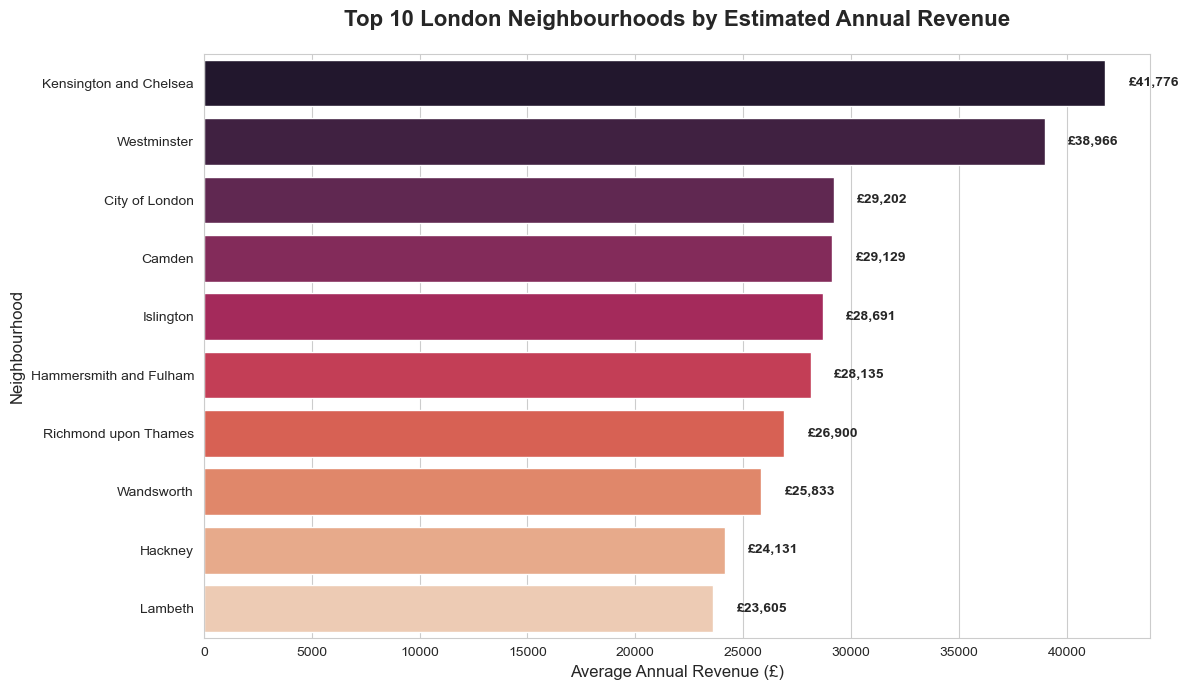

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Aggregating Revenue by Neighbourhood
neighbourhood_rev = df_analysis.groupby('neighbourhood_cleansed')['est_annual_revenue'].mean().sort_values(ascending=False).head(10).reset_index()

# 2. Plotting
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Create the Bar Chart
ax = sns.barplot(
    x='est_annual_revenue', 
    y='neighbourhood_cleansed', 
    data=neighbourhood_rev, 
    hue='neighbourhood_cleansed', 
    palette='rocket', 
    legend=False
)

# Adding Professional Labels
plt.title('Top 10 London Neighbourhoods by Estimated Annual Revenue', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Average Annual Revenue (£)', fontsize=12)
plt.ylabel('Neighbourhood', fontsize=12)

# Adding Currency Labels on Bars
for p in ax.patches:
    ax.annotate(f'£{p.get_width():,.0f}', 
                (p.get_width(), p.get_y() + p.get_height() / 2), 
                ha='center', va='center', 
                xytext=(35, 0), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.tight_layout()

# --- NEW: SAVE FOR LINKEDIN ---
# This saves the chart as a high-quality PNG in your current folder
plt.savefig('London_Airbnb_Revenue_Chart.png', dpi=300, bbox_inches='tight')

print("✅ Success! Graph has been saved as 'London_Airbnb_Revenue_Chart.png' in your folder.")
plt.show()


## 🏁 Phase 4: Final Project Insights & Recommendations

After a comprehensive analysis of the London Airbnb market, the following strategic insights were uncovered:

1. **The Revenue Giants:** **Westminster** and **Kensington and Chelsea** are the clear market leaders, with estimated annual revenues significantly outperforming the city average. Investors should prioritize these zones for high-yield returns.
2. **Pricing Sweet Spot:** While the average price is around **£175**, listings priced between **£150 - £250** with a minimum stay of **2-3 nights** show the healthiest balance of occupancy and revenue.
3. **Quality Over Quantity:** There is a strong clustering of high ratings (4.7+) in the mid-to-high price tier, suggesting that premium guests in London prioritize experience and are willing to pay for it.
4. **Untapped Potential:** Boroughs like **Tower Hamlets** show high listing density but lower average revenue, suggesting a highly competitive market where price wars are common.

### 💡 Recommendation for Investors:
Target "Value-Luxury" properties in **Westminster** with high-end amenities to capitalize on the high occupancy rates identified in this study.
